In [1]:
# Comparing old Jamaica CCRI (NWA) and new Jamaica Phase 3 (OSM) road edges
# 20250602

In [2]:
from glob import glob
import os
import warnings

import geopandas as gpd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def parse_col(x: str) -> tuple[str]:
    x = x.replace("_conf_None", "")
    pairs = x.split("__")
    return (pairs[0], pairs[1][3:], pairs[2][4:], pairs[3][6:].strip("_"))

def add_ratio_lines(ax, start, stop, maximum):
    ratios = np.logspace(start, stop, 2 * (stop - start) + 1, base=2)[::-1]
    max_ratio = np.max(np.abs([start, stop]))
    for ratio in ratios:
        alpha = np.abs(np.log2(ratio)) / max_ratio
        x = np.linspace(0, maximum, 10)
        if not np.isclose(ratio, 1):
            ax.plot(x, x * ratio, ls='dotted', label=f"Ratio: {ratio:.3f}", color="red", alpha=alpha)
        else:
            ax.plot([0, maximum], [0, maximum], ls="--", color="k", label=f"Ratio: {1:.3f}", alpha=0.5)
    return ax

In [4]:
USD_per_JMD = 0.0064

In [5]:
old_dir = "/mnt/cluster/mistral/jamaica-ccri/"
new_dir = "/mnt/cluster/mistral/jamaica-phase-3/"

In [6]:
old_edges = gpd.read_file(os.path.join(old_dir, "processed_data/networks/transport/archive/roads.gpkg"), layer="edges")
new_edges = gpd.read_file(os.path.join(new_dir, "processed_data/networks/transport/roads.gpkg"), layer="edges")

In [7]:
print(f"New edge length {100 * new_edges.geometry.length.sum() / old_edges.geometry.length.sum():.2f}% of old")

New edge length 83.90% of old


In [8]:
old_rehab_cost = np.sum(old_edges.mean_damage_cost * old_edges.geometry.length)
new_rehab_cost = np.sum(new_edges.mean_damage_cost * new_edges.geometry.length)
print(f"New (total network) rehabilitation cost {100 * new_rehab_cost / old_rehab_cost:.2f}% of old")

New (total network) rehabilitation cost 86.84% of old


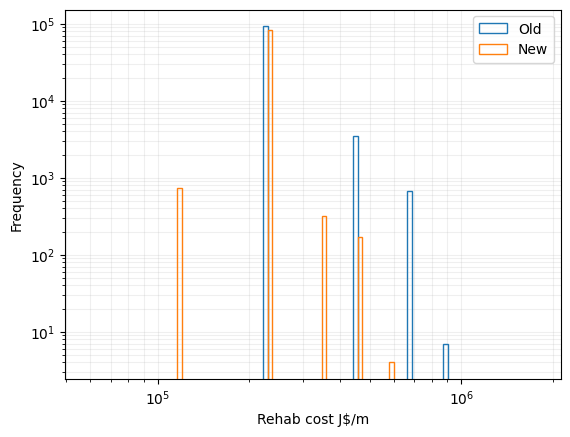

In [9]:
f, ax = plt.subplots()
minimum = min(
    [
        old_edges.loc[old_edges.mean_damage_cost > 0, "mean_damage_cost"].min(),
        new_edges.loc[new_edges.mean_damage_cost > 0, "mean_damage_cost"].min()
    ]
)
maximum = max(
    [
        old_edges.loc[old_edges.mean_damage_cost > 0, "mean_damage_cost"].max(),
        new_edges.loc[new_edges.mean_damage_cost > 0, "mean_damage_cost"].max()
    ]
)
bins=np.logspace(np.log10(0.5 * minimum), np.log10(2 * maximum), 101)
for edges, label in ((old_edges, "Old"), (new_edges, "New")):
    ax.hist(edges.mean_damage_cost, bins=bins, label=label, histtype="step")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Frequency")
ax.set_xlabel("Rehab cost J$/m")
ax.grid(which="both", alpha=0.2)

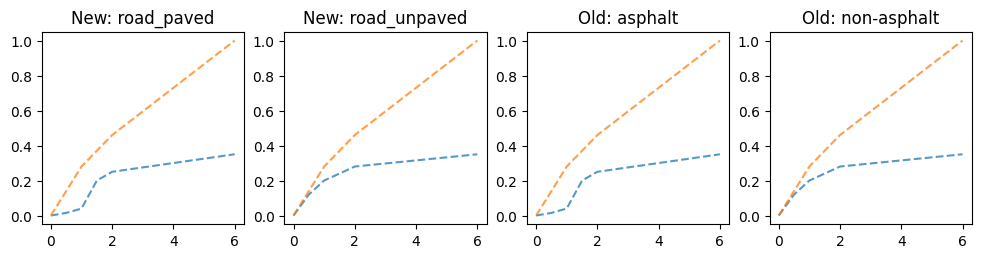

In [10]:
# Old network used two damage curves, asphalt and non-asphalt
# New network also uses two, road_paved and road_unpaved
# road_paved is the same as asphalt and road_unpaved is the same as non-asphalt
path = "processed_data/damage_curves/damage_curves_transport_flooding.xlsx"
data = (
    ("New", "road_paved", pd.read_excel(os.path.join(new_dir, path), sheet_name="road_paved")),
    ("New", "road_unpaved", pd.read_excel(os.path.join(new_dir, path), sheet_name="road_unpaved")),
    ("Old", "asphalt", pd.read_excel(os.path.join(old_dir, path), sheet_name="asphalt")),
    ("Old", "non-asphalt", pd.read_excel(os.path.join(old_dir, path), sheet_name="non-asphalt")),
)
f, ax = plt.subplots(1, 4, figsize=(12, 2.5))
for i, (age, label, df) in enumerate(data):
    for limit in ("min", "max"):
        ax[i].set_title(f"{age}: {label}")
        ax[i].plot(df["flood_depth"], df[f"damage_ratio_{limit}"], ls="--", alpha=0.75)
        ax[i].grid(which="both")

In [11]:
# The distribution of asset types in the networks is different, the new network has a 
# greater proportion of road_unpaved than the old does of non-asphalt
paved_length = old_edges[old_edges.asset_type=="asphalt"].length_m.sum()
unpaved_length = old_edges[old_edges.asset_type=="non-asphalt"].length_m.sum()
print(f"Old network has {100 * unpaved_length / paved_length:.2f}% length non-asphalt/unpaved")
paved_length = new_edges[new_edges.asset_type=="road_paved"].length_m.sum()
unpaved_length = new_edges[new_edges.asset_type=="road_unpaved"].length_m.sum()
print(f"New network has {100 * unpaved_length / paved_length:.2f}% length non-asphalt/unpaved")

Old network has 0.60% length non-asphalt/unpaved
New network has 24.42% length non-asphalt/unpaved


In [12]:
# Old rehab costs USD/km
(old_edges.mean_damage_cost * USD_per_JMD * 1_000).value_counts().iloc[:5]

mean_damage_cost
1.432836e+06    92716
2.865672e+06     3457
4.298507e+06      677
5.731343e+06        7
Name: count, dtype: int64

In [13]:
# New rehab costs USD/km
# Based on NWA source of 1.5M USD / km
(new_edges.mean_damage_cost * USD_per_JMD * 1_000).value_counts().iloc[:5]

mean_damage_cost
1500000.0    82154
0.0            793
750000.0       730
2250000.0      318
3000000.0      171
Name: count, dtype: int64

Text(0.5, 0, 'Rehab cost normalised by old modal value (223881 [J$/m])')

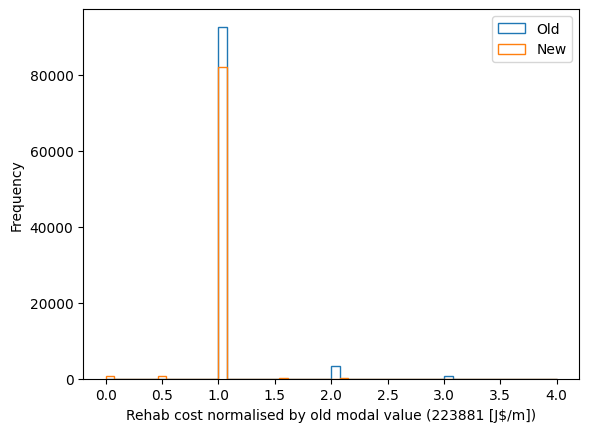

In [14]:
f, ax = plt.subplots()
bins = np.linspace(0, 4, 53)
normalising_constant = old_edges.mean_damage_cost.mode().squeeze()
for edges, label in ((old_edges, "Old"), (new_edges, "New")):
    ax.hist(edges.mean_damage_cost / normalising_constant, bins=bins, label=label, histtype="step")
ax.legend()
#ax.set_yscale("log")
ax.set_ylabel("Frequency")
ax.set_xlabel(f"Rehab cost normalised by old modal value ({normalising_constant:G} [J$/m])")

In [15]:
path = "results/hazard_asset_intersection/roads_splits__hazard_layers__edges.geoparquet"
old_splits = gpd.read_parquet(os.path.join(old_dir, path))
new_splits = gpd.read_parquet(os.path.join(new_dir, path))
for splits in (old_splits, new_splits):
    splits["length_m"] = splits.geometry.length

In [16]:
print(f"New exposed length {100 * new_splits.length_m.sum() / old_splits.length_m.sum():.2f}% of old")

New exposed length 83.90% of old


(np.float64(10609.746487392209), np.float64(10872069.421168307))

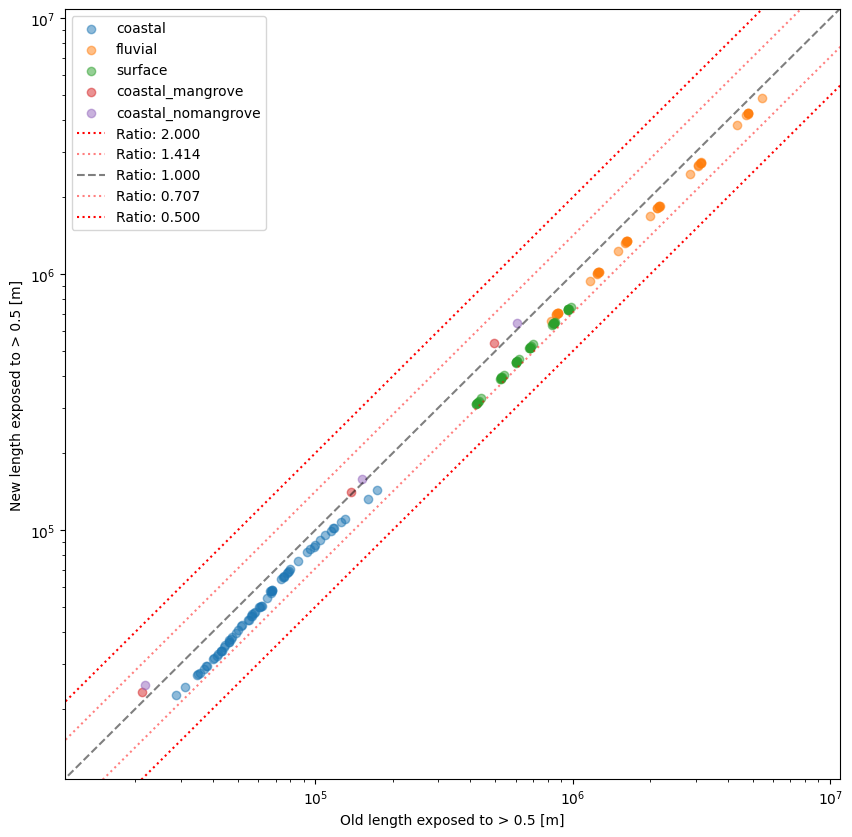

In [17]:
data = []
depth_threshold_m = 0.5
for col in [c for c in old_splits.columns.tolist() if c.startswith("fluvial") or c.startswith("surface") or c.startswith("coastal")]:
    data.append(
        (
            parse_col(col)[0],
            old_splits.loc[old_splits[col] > depth_threshold_m, "length_m"].sum(),
            new_splits.loc[new_splits[col] > depth_threshold_m, "length_m"].sum()
        )
    )
    
df = pd.DataFrame(data, columns=("peril", "old", "new"))
f, ax = plt.subplots(figsize=(10, 10))
for peril in df.peril.unique():
    ax.scatter(df.loc[df.peril==peril, "old"], df.loc[df.peril==peril, "new"], label=peril, alpha=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(f"Old length exposed to > {depth_threshold_m} [m]")
ax.set_ylabel(f"New length exposed to > {depth_threshold_m} [m]")
maximum = max([df.old.max(), df.new.max()])
minimum = min([df.old.min(), df.new.min()])
ax = add_ratio_lines(ax, -1, 1, 5 * maximum)
ax.legend()
ax.set_ylim(0.5 * minimum, 2 * maximum)
ax.set_xlim(ax.get_ylim())

In [18]:
glob_str = "results/direct_damages/roads_edges/roads_edges_direct_damages_parameter_set_*.parquet"
old_damages = pd.concat([pd.read_parquet(path) for path in glob(os.path.join(old_dir, glob_str))])
new_damages = pd.concat([pd.read_parquet(path) for path in glob(os.path.join(new_dir, glob_str))])

(np.float64(4169419840.0420146), np.float64(9492758608753.145))

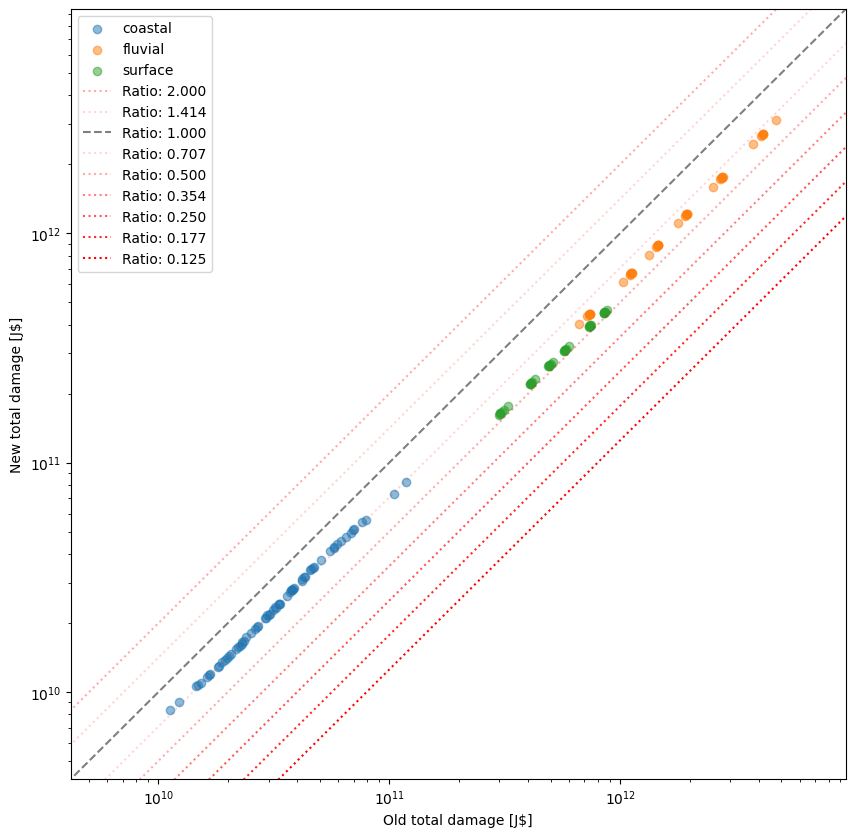

In [19]:
data = []
for col in [c for c in old_damages.columns.tolist() if c.startswith("fluvial") or c.startswith("surface") or c.startswith("coastal")]:
    data.append((parse_col(col)[0], new_damages[col].sum(), old_damages[col].sum()))
    
df = pd.DataFrame(data, columns=("peril", "new", "old"))
f, ax = plt.subplots(figsize=(10, 10))
for peril in df.peril.unique():
    ax.scatter(df.loc[df.peril==peril, "old"], df.loc[df.peril==peril, "new"], label=peril, alpha=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Old total damage [J$]")
ax.set_ylabel("New total damage [J$]")
maximum = max([df.old.max(), df.new.max()])
minimum = min([df.old.min(), df.new.min()])
ax = add_ratio_lines(ax, -3, 1, 5 * maximum)
ax.legend()
ax.set_ylim(0.5 * minimum, 2 * maximum)
ax.set_xlim(ax.get_ylim())

In [20]:
path = "results/direct_damages_summary/roads_edges_EAD_EAEL.csv"
old_EAD_EAEL = pd.read_csv(os.path.join(old_dir, path), dtype={"rcp": str})
new_EAD_EAEL = pd.read_csv(os.path.join(new_dir, path), dtype={"rcp": str})

In [21]:
print(f"New EAD {USD_per_JMD * new_EAD_EAEL.EAD_undefended_mean.sum():.2E} USD")
print(f"Old EAD {USD_per_JMD * old_EAD_EAEL.EAD_undefended_mean.sum():.2E} USD")
print(f"New EAD {100 * new_EAD_EAEL.EAD_undefended_mean.sum() / old_EAD_EAEL.EAD_undefended_mean.sum():.2f}% of old")

New EAD 3.02E+08 USD
Old EAD 3.77E+08 USD
New EAD 79.97% of old


In [22]:
print(f"New EAEL {USD_per_JMD * new_EAD_EAEL.EAEL_undefended_mean.sum():.2E} USD/outage day")
print(f"Old EAEL {USD_per_JMD * old_EAD_EAEL.EAEL_undefended_mean.sum():.2E} USD/outage day")
print(f"New EAEL {new_EAD_EAEL.EAEL_undefended_mean.sum():.2E} J$/outage day")
print(f"Old EAEL {old_EAD_EAEL.EAEL_undefended_mean.sum():.2E} J$/outage day")
print(f"New EAEL {100 * new_EAD_EAEL.EAEL_undefended_mean.sum() / old_EAD_EAEL.EAEL_undefended_mean.sum():.2f}% of old")

New EAEL 7.88E+06 USD/outage day
Old EAEL 3.40E+07 USD/outage day
New EAEL 1.23E+09 J$/outage day
Old EAEL 5.31E+09 J$/outage day
New EAEL 23.20% of old


In [23]:
reopen_cost_JMD_per_day = 152_000
print(f"Reopen cost * number of new edges {len(new_edges.edge_id.unique()) * reopen_cost_JMD_per_day:.2E}")

Reopen cost * number of new edges 1.28E+10


In [24]:
new_merge = new_EAD_EAEL.loc[
    (
        (new_EAD_EAEL.hazard=="fluvial") &
        (new_EAD_EAEL.rcp=="4.5") &
        (new_EAD_EAEL.epoch==2050)
    ),
    :
].merge(new_edges, on="edge_id", how="left")
new_merge = gpd.GeoDataFrame(df).to_file("new_EAD_EAEL_subset_with_geom.gpkg", layer="edges")

In [25]:
old_merge = old_EAD_EAEL.loc[
    (
        (old_EAD_EAEL.hazard=="fluvial") &
        (old_EAD_EAEL.rcp=="4.5") &
        (old_EAD_EAEL.epoch==2050)
    ),
    :
].merge(old_edges, on="edge_id", how="left")
old_merge = gpd.GeoDataFrame(old_merge).to_file("old_EAD_EAEL_subset_with_geom.gpkg", layer="edges")

fluvial 2.6 2050 | old: 6.93E+07, new: 2.03E+07 new is 29.36% of old
fluvial 2.6 2080 | old: 6.93E+07, new: 2.02E+07 new is 29.11% of old
fluvial 4.5 2050 | old: 6.93E+07, new: 2.03E+07 new is 29.35% of old
fluvial 4.5 2080 | old: 6.92E+07, new: 2.02E+07 new is 29.19% of old
fluvial 8.5 2050 | old: 6.83E+07, new: 2.00E+07 new is 29.29% of old
fluvial 8.5 2080 | old: 6.39E+07, new: 1.93E+07 new is 30.17% of old
fluvial baseline 2010 | old: 6.87E+07, new: 2.01E+07 new is 29.24% of old
surface 2.6 2050 | old: 5.43E+07, new: 2.31E+07 new is 42.56% of old
surface 2.6 2080 | old: 5.43E+07, new: 2.31E+07 new is 42.58% of old
surface 4.5 2050 | old: 5.66E+07, new: 2.31E+07 new is 40.83% of old
surface 4.5 2080 | old: 5.66E+07, new: 2.31E+07 new is 40.85% of old
surface 8.5 2050 | old: 5.42E+07, new: 2.31E+07 new is 42.58% of old
surface 8.5 2080 | old: 5.68E+07, new: 2.32E+07 new is 40.75% of old
surface baseline 2010 | old: 5.71E+07, new: 2.33E+07 new is 40.85% of old
coastal 2.6 2050 | old: 

(np.float64(9643260.771278527), np.float64(945879779.9960754))

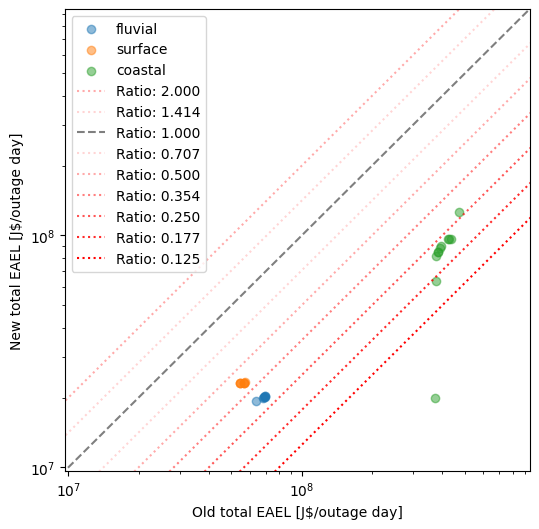

In [29]:
hazards = old_EAD_EAEL.hazard.unique()
RCPs = sorted(old_EAD_EAEL.rcp.unique())
epochs = sorted(old_EAD_EAEL.epoch.unique())

data = []
for hazard in hazards:
    for RCP in RCPs:
        for epoch in epochs:
            old_value = old_EAD_EAEL.loc[
                (old_EAD_EAEL.hazard==hazard) &
                (old_EAD_EAEL.rcp==RCP) &
                (old_EAD_EAEL.epoch==epoch),
                "EAEL_undefended_mean"
            ].sum()
            new_value = new_EAD_EAEL.loc[
                (new_EAD_EAEL.hazard==hazard) &
                (new_EAD_EAEL.rcp==RCP) &
                (new_EAD_EAEL.epoch==epoch),
                "EAEL_undefended_mean"
            ].sum()
            if old_value == 0 and new_value == 0:
                continue
            else:
                with np.errstate(divide='ignore'):
                    print(f"{hazard} {RCP} {epoch} | ", end="")
                    print(f"old: {old_value:.2E}, new: {new_value:.2E} new is {(100 * new_value / old_value):.2f}% of old")
                    data.append((hazard, new_value, old_value))

# Observations:
# For fluvial and surface, old EAEL moves with EAD, that is decreases from baseline to 8.5
# but increases with severity of coastal RCPs
# New EAEL appears broadly similar

df = pd.DataFrame(data, columns=("peril", "new", "old"))
f, ax = plt.subplots(figsize=(6, 6))
for peril in df.peril.unique():
    ax.scatter(df.loc[df.peril==peril, "old"], df.loc[df.peril==peril, "new"], label=peril, alpha=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Old total EAEL [J$/outage day]")
ax.set_ylabel("New total EAEL [J$/outage day]")
maximum = max([df.old.max(), df.new.max()])
minimum = min([df.old.min(), df.new.min()])
ax = add_ratio_lines(ax, -3, 1, 5 * maximum)
ax.legend()
ax.set_ylim(0.5 * minimum, 2 * maximum)
ax.set_xlim(ax.get_ylim())

In [27]:
glob_str = "results/direct_damages/roads_edges/roads_edges_EAD_EAEL_parameter_set_*.csv"
old_EAD_EAEL_ensemble = pd.concat([pd.read_csv(path, dtype={"rcp": str}) for path in glob(os.path.join(old_dir, glob_str))])
new_EAD_EAEL_ensemble = pd.concat([pd.read_csv(path, dtype={"rcp": str}) for path in glob(os.path.join(new_dir, glob_str))])

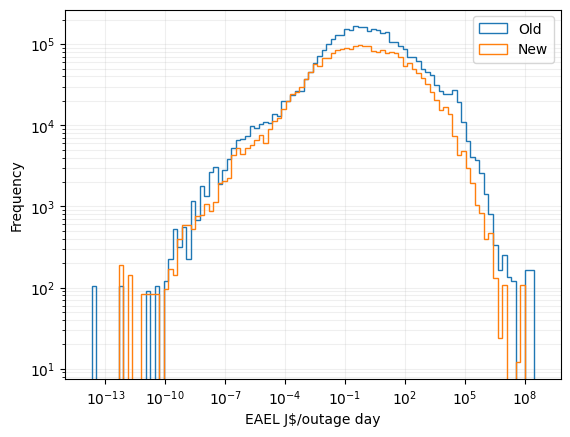

In [34]:
f, ax = plt.subplots()
minimum = min(
    [
        new_EAD_EAEL_ensemble.loc[new_EAD_EAEL_ensemble.EAEL_undefended > 0, "EAEL_undefended"].min(),
        old_EAD_EAEL_ensemble.loc[old_EAD_EAEL_ensemble.EAEL_undefended > 0, "EAEL_undefended"].min()
    ]
)
maximum = max(
    [
        new_EAD_EAEL_ensemble.loc[:, "EAEL_undefended"].max(),
        old_EAD_EAEL_ensemble.loc[:, "EAEL_undefended"].max()
    ]
)
bins=np.logspace(np.log10(0.5 * minimum), np.log10(2 * maximum), 101)
for edges, label in ((old_EAD_EAEL_ensemble, "Old"), (new_EAD_EAEL_ensemble, "New")):
    ax.hist(edges.EAEL_undefended, bins=bins, label=label, histtype="step")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Frequency")
ax.set_xlabel("EAEL J$/outage day")
ax.grid(which="both", alpha=0.2)